# Gaussian Mixture Model (GMM)

Gaussian Mixture Model (GMM) predstavlja probabilisticki pristup klasterovanju koji pretpostavlja da podaci poticu iz vise razlicitih Gausovih raspodela. Za razliku od KMeans algoritma, koji svaku instancu strogo dodeljuje jednom klasteru, GMM svakoj instanci pridruzuje verovatnocu pripadnosti svakom klasteru.

Osnovna pretpostavka algoritma jeste da se skup podataka moze opisati kao mesavina vise normalnih raspodela, pri cemu svaka raspodela predstavlja jedan klaster.

Svaki klaster karakterisu tri osnovna parametra:

- srednja vrednost (mean),
- matrica kovarijanse (covariance),
- tezina klastera (mixing coefficient).

Za svaku instancu algoritam izracunava verovatnocu da je generisana iz svake od Gausovih raspodela. Na osnovu tih verovatnoca procenjuje se pripadnost klasterima.

Parametri modela se odredjuju primenom **Expectation-Maximization (EM)** algoritma koji se sastoji od dva koraka:

### E-korak (Expectation)

Na osnovu trenutnih parametara modela izracunava se verovatnoca pripadnosti svake instance svakom klasteru.

### M-korak (Maximization)

Koristeci dobijene verovatnoce, azuriraju se parametri svih Gausovih raspodela kako bi se bolje opisali podaci.

Ova dva koraka se ponavljaju sve dok model ne dostigne stabilno resenje.

Glavne prednosti GMM algoritma su:

- omogucava meku pripadnost klasterima,
- moze modelovati klastere razlicitih oblika i velicina,
- fleksibilniji je od KMeans algoritma kada podaci ne formiraju sferne klastere.

Sa druge strane, potrebno je unapred zadati broj klastera, a algoritam je racunski zahtevniji od KMeans pristupa i osetljiviji na inicijalizaciju parametara.

U nastavku ce biti analiziran uticaj broja klastera i broja PCA komponenti na kvalitet grupisanja pomocu Gaussian Mixture Model algoritma.

In [ ]:
import pandas as pd
X_scaled = pd.read_csv("../../data/data_full_scaled.csv")

In [3]:
X_scaled = X_scaled.drop(columns=["Unnamed: 0"])

Kako je Gaussian Mixture Model racunski zahtevniji od KMeans algoritma, eksperimenti su sprovedeni nad slucajnim uzorkom od 10000 instanci.

Za svaku PCA reprezentaciju sa 3 do 10 komponenti trenirani su GMM modeli sa brojem klastera od 2 do 10. Pored Silhouette Score pokazatelja, pracene su i vrednosti BIC i AIC kriterijuma, kao i raspodela instanci po klasterima.

Cilj analize je pronalazak konfiguracije koja ostvaruje dobar kvalitet grupisanja uz dovoljno uravnotezene i interpretabilne klastere.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

sample_size = min(10000, X_scaled.shape[0])

sample_idx = np.random.RandomState(42).choice(
    X_scaled.shape[0],
    size=sample_size,
    replace=False
)

pca_samples = {}

for n_components in range(3, 11):

    pca = PCA(
        n_components=n_components,
        random_state=42
    )
    X_pca = pca.fit_transform(X_scaled)

    pca_samples[f"pca_{n_components}"] = {
        "X_full": X_pca,
        "X_sample": X_pca[sample_idx],
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "pca_model": pca
    }

for name, data in pca_samples.items():
    print(
        name,
        "full:", data["X_full"].shape,
        "sample:", data["X_sample"].shape,
        "var:", round(data["explained_variance"], 4)
    )

pca_3 full: (123849, 3) sample: (10000, 3) var: 0.0269
pca_4 full: (123849, 4) sample: (10000, 4) var: 0.0325
pca_5 full: (123849, 5) sample: (10000, 5) var: 0.038
pca_6 full: (123849, 6) sample: (10000, 6) var: 0.0434
pca_7 full: (123849, 7) sample: (10000, 7) var: 0.0487
pca_8 full: (123849, 8) sample: (10000, 8) var: 0.0538
pca_9 full: (123849, 9) sample: (10000, 9) var: 0.0589
pca_10 full: (123849, 10) sample: (10000, 10) var: 0.0639


### Evaluacija GMM modela

Za svaku kombinaciju PCA dimenzionalnosti i broja klastera treniran je poseban Gaussian Mixture Model.

Kvalitet modela procenjivan je pomocu sledecih metrika:

- **Silhouette Score** - meri koliko su instance bliske svom klasteru, a udaljene od ostalih klastera. Vece vrednosti ukazuju na bolje razdvojene i kompaktnije klastere.

- **BIC (Bayesian Information Criterion)** - procenjuje kvalitet statistickog modela uz penalizaciju slozenosti. Niza vrednost BIC kriterijuma ukazuje na bolji balans izmedju kvaliteta uklapanja modela i broja parametara koje model koristi. Zbog jace penalizacije slozenijih modela, BIC cesto favorizuje manji broj klastera.

- **AIC (Akaike Information Criterion)** - slican je BIC kriterijumu i koristi se za poredjenje statistickih modela. Takodje kombinuje kvalitet uklapanja i slozenost modela, ali primenjuje slabiju penalizaciju velikog broja parametara. Zbog toga AIC cesce favorizuje modele sa vecim brojem klastera u odnosu na BIC.

Za obe metrike apsolutna vrednost nema posebno znacenje. Koriste se iskljucivo za medjusobno poredjenje modela, pri cemu se boljim smatra model sa manjom vrednoscu kriterijuma.

Pored navedenih metrika analizirana je i raspodela instanci po klasterima kako bi se izbegao izbor modela koji ostvaruje visok rezultat na metrikama, ali proizvodi izrazito neuravnotezene klastere.

In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

gmm_results = []

for pca_dim in range(3, 11):

    X = pca_samples[f"pca_{pca_dim}"]["X_sample"]
    explained_variance = pca_samples[f"pca_{pca_dim}"]["explained_variance"]

    for k in range(2, 11):

        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42
        )

        labels = gmm.fit_predict(X)

        silhouette = silhouette_score(X, labels)
        bic = gmm.bic(X)
        aic = gmm.aic(X)

        cluster_sizes = pd.Series(labels).value_counts()

        gmm_results.append({
            "pca_dim": pca_dim,
            "explained_variance": explained_variance,
            "k": k,
            "silhouette": silhouette,
            "bic": bic,
            "aic": aic,
            "min_cluster_size": cluster_sizes.min(),
            "max_cluster_size": cluster_sizes.max(),
            "smallest_cluster_pct": cluster_sizes.min() / len(labels) * 100,
            "largest_cluster_pct": cluster_sizes.max() / len(labels) * 100
        })

gmm_results = pd.DataFrame(gmm_results)

gmm_results.sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,bic,aic,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
7,3,0.026899,9,0.253843,90170.309894,89528.589601,192,1604,1.92,16.04
8,3,0.026899,10,0.249801,90192.165208,89478.341511,192,1529,1.92,15.29
2,3,0.026899,4,0.244856,91293.996680,91012.793405,2024,3094,20.24,30.94
5,3,0.026899,7,0.244149,90866.926925,90369.413439,1059,2021,10.59,20.21
6,3,0.026899,8,0.236803,90893.814575,90324.197686,801,1597,8.01,15.97
1,3,0.026899,3,0.225339,92069.848051,91860.748180,2549,4771,25.49,47.71
3,3,0.026899,5,0.205037,91186.608778,90833.302100,960,3078,9.60,30.78
0,3,0.026899,2,0.202509,94660.960206,94523.963739,3983,6017,39.83,60.17
4,3,0.026899,6,0.199203,90982.268685,90556.858603,605,3140,6.05,31.40
9,4,0.032507,2,0.185962,122725.033132,122515.933262,3616,6384,36.16,63.84


In [6]:
gmm_results[
    gmm_results["smallest_cluster_pct"] >= 3
].sort_values(
    "silhouette",
    ascending=False
).head(20)

,pca_dim,explained_variance,k,silhouette,bic,aic,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
2,3,0.026899,4,0.244856,91293.996680,91012.793405,2024,3094,20.24,30.94
5,3,0.026899,7,0.244149,90866.926925,90369.413439,1059,2021,10.59,20.21
6,3,0.026899,8,0.236803,90893.814575,90324.197686,801,1597,8.01,15.97
1,3,0.026899,3,0.225339,92069.848051,91860.748180,2549,4771,25.49,47.71
3,3,0.026899,5,0.205037,91186.608778,90833.302100,960,3078,9.60,30.78
0,3,0.026899,2,0.202509,94660.960206,94523.963739,3983,6017,39.83,60.17
4,3,0.026899,6,0.199203,90982.268685,90556.858603,605,3140,6.05,31.40
9,4,0.032507,2,0.185962,122725.033132,122515.933262,3616,6384,36.16,63.84
21,5,0.038036,5,0.181320,134095.730180,133345.854782,977,3669,9.77,36.69
13,4,0.032507,6,0.171763,115058.443228,114416.722935,550,2676,5.50,26.76


Nakon eliminacije konfiguracija koje formiraju veoma male klastere, najbolje rezultate ostvaruju modeli sa 3 PCA komponente. Najvisi Silhouette Score iznosi 0.245 za konfiguraciju sa 4 klastera, pri cemu najmanji klaster obuhvata oko 20% instanci, a najveci oko 31%.

Za razliku od Agglomerative Clustering i DBSCAN algoritama, kod kojih su najbolje konfiguracije cesto proizvodile izrazito neuravnotezene klastere, GMM uspeva da formira znatno uravnotezenije grupe. Razlike u velicini klastera postoje, ali nijedan klaster ne dominira skupom podataka.

Takodje se moze primetiti da najbolji rezultati uglavnom odgovaraju manjim PCA reprezentacijama, dok povecanje broja komponenti dovodi do postepenog opadanja Silhouette Score vrednosti. Ovo ukazuje da najvaznija struktura podataka moze biti opisana relativno malim brojem glavnih komponenti.

Na osnovu ovih rezultata, najperspektivnijim se pokazuje GMM model sa 3 PCA komponente i 4 klastera, koji ostvaruje najbolji odnos izmedju kvaliteta grupisanja i uravnotezenosti klastera.

In [7]:
gmm_results.sort_values("bic").head(20)

,pca_dim,explained_variance,k,silhouette,bic,aic,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
7,3,0.026899,9,0.253843,90170.309894,89528.589601,192,1604,1.92,16.04
8,3,0.026899,10,0.249801,90192.165208,89478.341511,192,1529,1.92,15.29
5,3,0.026899,7,0.244149,90866.926925,90369.413439,1059,2021,10.59,20.21
6,3,0.026899,8,0.236803,90893.814575,90324.197686,801,1597,8.01,15.97
4,3,0.026899,6,0.199203,90982.268685,90556.858603,605,3140,6.05,31.40
3,3,0.026899,5,0.205037,91186.608778,90833.302100,960,3078,9.60,30.78
2,3,0.026899,4,0.244856,91293.996680,91012.793405,2024,3094,20.24,30.94
1,3,0.026899,3,0.225339,92069.848051,91860.748180,2549,4771,25.49,47.71
0,3,0.026899,2,0.202509,94660.960206,94523.963739,3983,6017,39.83,60.17
16,4,0.032507,9,0.131684,113990.774523,113024.588913,425,2370,4.25,23.70


In [8]:
gmm_results.sort_values("aic").head(20)

,pca_dim,explained_variance,k,silhouette,bic,aic,min_cluster_size,max_cluster_size,smallest_cluster_pct,largest_cluster_pct
8,3,0.026899,10,0.249801,90192.165208,89478.341511,192,1529,1.92,15.29
7,3,0.026899,9,0.253843,90170.309894,89528.589601,192,1604,1.92,16.04
6,3,0.026899,8,0.236803,90893.814575,90324.197686,801,1597,8.01,15.97
5,3,0.026899,7,0.244149,90866.926925,90369.413439,1059,2021,10.59,20.21
4,3,0.026899,6,0.199203,90982.268685,90556.858603,605,3140,6.05,31.40
3,3,0.026899,5,0.205037,91186.608778,90833.302100,960,3078,9.60,30.78
2,3,0.026899,4,0.244856,91293.996680,91012.793405,2024,3094,20.24,30.94
1,3,0.026899,3,0.225339,92069.848051,91860.748180,2549,4771,25.49,47.71
0,3,0.026899,2,0.202509,94660.960206,94523.963739,3983,6017,39.83,60.17
17,4,0.032507,10,0.171085,114091.241006,113016.900291,403,2086,4.03,20.86


Pored Silhouette Score pokazatelja, analizirani su i BIC i AIC kriterijumi, koji predstavljaju standardne metrike za izbor Gaussian Mixture Model konfiguracija.

Rezultati pokazuju da obe metrike favorizuju modele sa vecim brojem klastera. Najmanje vrednosti BIC i AIC kriterijuma ostvaruju konfiguracije sa 9 i 10 klastera, sto ukazuje da slozeniji modeli bolje opisuju raspodelu podataka.

Medjutim, detaljnijom analizom velicine klastera moze se primetiti da kod ovih konfiguracija najmanji klasteri sadrze svega oko 2% instanci. Iako takvi modeli ostvaruju povoljne vrednosti statistickih kriterijuma, oni proizvode klastere koji postaju sve manji i tezi za interpretaciju.

Sa druge strane, konfiguracija sa 4 klastera ostvaruje nesto vise vrednosti BIC i AIC kriterijuma, ali formira znatno uravnotezenije klastere. Najmanji klaster obuhvata oko 20% instanci, dok najveci sadrzi oko 31%, sto predstavlja znatno prirodniju segmentaciju podataka.

Zbog toga se prilikom izbora konacnog modela BIC i AIC ne posmatraju izolovano, vec zajedno sa Silhouette Score pokazateljem i raspodelom instanci po klasterima. Na taj nacin dobija se model koji ne samo da dobro opisuje podatke, vec omogucava i smisleniju interpretaciju dobijenih grupa.

### Izbor konfiguracija za detaljnu analizu

Iako su BIC i AIC kriterijumi favorizovali modele sa vecim brojem klastera, konacan izbor nije donet iskljucivo na osnovu ovih metrika.

Konfiguracija sa 4 klastera ostvaruje najbolju ravnotezu izmedju kvaliteta grupisanja i uravnotezenosti klastera, dok konfiguracije sa 9 i 10 klastera ostvaruju najpovoljnije vrednosti BIC i AIC kriterijuma, ali uz veci broj manjih grupa.

Zbog toga su za dalju evaluaciju izabrane dve konfiguracije:

- GMM sa 4 klastera, kao model koji ostvaruje najbolji kompromis izmedju metrika i interpretabilnosti,
- GMM sa 9 klastera, kao model koji je prema BIC kriterijumu najbolje opisao strukturu podataka.

Cilj dodatne analize je da se kroz ispitivanje atributa, raspodele instanci i karakteristika klastera utvrdi koja od ove dve konfiguracije bolje odgovara stvarnoj strukturi analiziranog skupa podataka.

In [9]:
best_gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

labels_gmm = best_gmm.fit_predict(
    pca_samples["pca_3"]["X_full"]
)

In [10]:
pd.Series(labels_gmm).value_counts(normalize=True) * 100

2    31.301020
0    23.877464
3    23.095059
1    21.726457
Name: proportion, dtype: float64

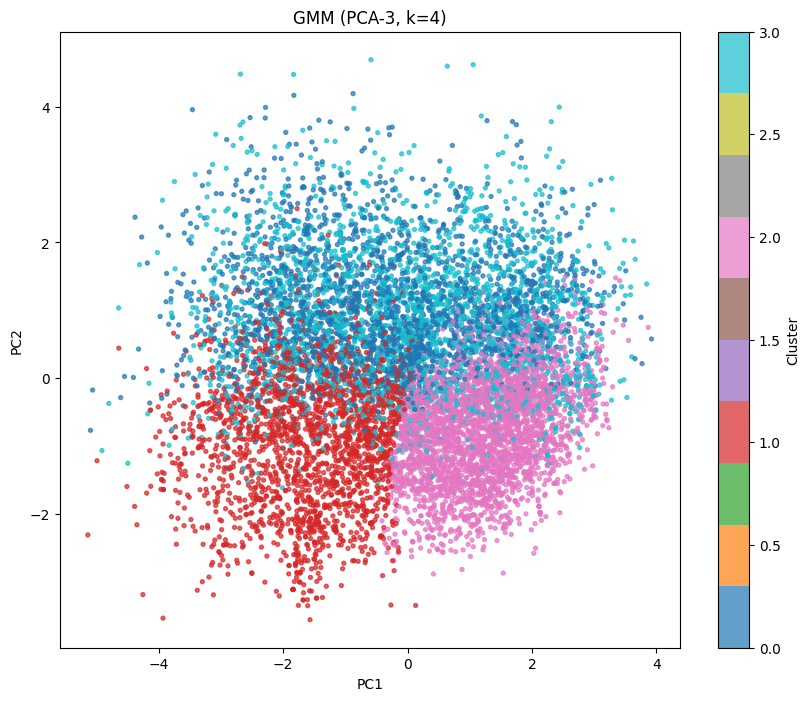

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(
    pca_samples["pca_3"]["X_sample"]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=labels_gmm[sample_idx],
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("GMM (PCA-3, k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [12]:
print(pca_samples["pca_3"].keys())

dict_keys(['X_full', 'X_sample', 'explained_variance', 'pca_model'])


In [13]:
best_gmm = GaussianMixture(
    n_components=9,
    covariance_type="full",
    random_state=42
)

labels_gmm_9 = best_gmm.fit_predict(
    pca_samples["pca_3"]["X_full"]
)

pd.Series(labels_gmm_9).value_counts(normalize=True).sort_index() * 100

0    15.064312
1    11.554393
2     1.751326
3     9.706174
4    21.982414
5    11.269368
6     8.903584
7    11.280672
8     8.487755
Name: proportion, dtype: float64

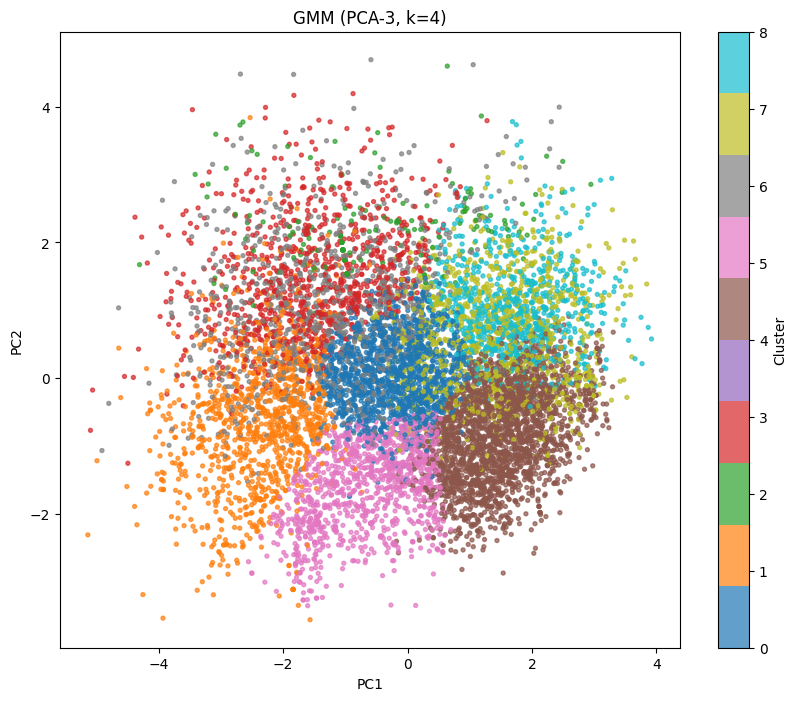

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_vis = PCA(
    n_components=2,
    random_state=42
).fit_transform(
    pca_samples["pca_3"]["X_sample"]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=labels_gmm_9[sample_idx],
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.title("GMM (PCA-3, k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")

plt.show()

### Vizuelna analiza

Radi lakse interpretacije analizirane su dve reprezentativne konfiguracije:

- GMM sa 4 klastera
- GMM sa 9 klastera

Kod konfiguracije sa 4 klastera primecuje se veoma slicna struktura kao kod KMeans algoritma. Prostor je podeljen na nekoliko velikih regiona koji se uglavnom mogu opisati kao gornji, donji, levi i desni deo prostora.

Takva segmentacija daje stabilne i lako interpretabilne klastere, uz Silhouette Score vrednost od približno 0.245.

Kod konfiguracije sa 9 klastera GMM pokazuje svoju glavnu prednost u odnosu na KMeans. Umesto nekoliko velikih grupa, algoritam dodatno deli centralni region prostora i formira vise manjih klastera razlicitih oblika. Na taj nacin model uspeva da opise finiju strukturu podataka.

Medjutim, iako je broj klastera veci, ne dolazi do znacajnog poboljsanja kvaliteta klasterovanja. Vizuelna analiza pokazuje da podaci i dalje formiraju jedan veliki kontinuirani oblak bez jasno odvojenih grupa. Zbog toga dodatna segmentacija ne donosi znacajnu korist i moze se posmatrati kao prekomerna podela prostora.

In [ ]:
pd.Series(labels_gmm).to_csv(
    "../../models/gmm_labels.csv",
    index = False
)

In [ ]:
pd.Series(labels_gmm_9).to_csv(
    "../../models/gmm_9_labels.csv",
    index = False
)